In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv2.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [41]:
SEEDS = [i for i in range(50, 75)]

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]

In [30]:
def loss_mae(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += abs((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0])
    return error / len(num + arrs)

def loss_mse(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    error = 0
    for i in arrs:
        m_params[i] = m_params[i].mean()
    for i in num + arrs:
        error += ((t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]) / t_params.loc[t_params["param"] == i, "std"].iloc[0]) ** 2
    return error / len(num + arrs)

def get_errors(paramsss, seeds, func):
    errors = []
    for seeed in seeds:
        random.seed(seeed)
        np.random.seed(seeed)
        exchange = ExchangeAgent(volume=paramsss['Exchange_Volume'], std=paramsss['Std'], transaction_cost=paramsss['Transaction_cost'], std_random=paramsss['Std_Random'], divs_drifted=True)
        simulator2 = Simulator(**{
            'exchange': exchange,
            'traders': [
                *[Random(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Random'])],
                *[Fundamentalist(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Fundamentalist'])],
                *[Chartist(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Chartist'])],
                *[Universalist(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Universalist'])],
                *[MarketMaker(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['MarketMaker'])],
            ],
        }, avg_traders=paramsss['Avg_Traders'], last_step=paramsss['Last_Step'], last_ret=paramsss['Last_Ret'], noisy_level=paramsss['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

        simulator2.simulate(1000, silent=True)
        prices = np.array(simulator2.info.prices)
        model_params = pipeline(prices, is_print=0)
        errors.append(func(target_params, model_params))
    return errors

In [5]:
study_mae_1000 = optuna.create_study(study_name="calibration_mae_v2 (Exception fixed)", direction="minimize", storage="sqlite:///calibration_mae_2.db",  load_if_exists=True)
study_mse_1000 = optuna.create_study(study_name="calibration_mse_v2 (Exceptions fixed)", direction="minimize", storage="sqlite:///calibration_mse_2.db",  load_if_exists=True)
study_mae_10000 = optuna.create_study(study_name="calibration_mae_2(10000)", direction="minimize", storage="sqlite:///calibration_mae_2(10000).db",  load_if_exists=True)
study_mse_10000 = optuna.create_study(study_name="calibration_mse_2(10000)", direction="minimize", storage="sqlite:///calibration_mse_2(10000)",  load_if_exists=True)
study_mae_dynamic = optuna.create_study(study_name="calibration_mae_v3 (mm-;volume+;diff diap)", direction="minimize", storage="sqlite:///calibration_mae_3.db",  load_if_exists=True)
study_mse_dynamic = optuna.create_study(study_name="calibration_mse_v3 (mm-;volume+;diff diap)", direction="minimize", storage="sqlite:///calibration_mse_3.db",  load_if_exists=True)

[I 2026-03-30 17:50:10,667] Using an existing study with name 'calibration_mae_v2 (Exception fixed)' instead of creating a new one.
[I 2026-03-30 17:50:10,708] Using an existing study with name 'calibration_mse_v2 (Exceptions fixed)' instead of creating a new one.
[I 2026-03-30 17:50:10,727] Using an existing study with name 'calibration_mae_2(10000)' instead of creating a new one.
[I 2026-03-30 17:50:10,745] Using an existing study with name 'calibration_mse_2(10000)' instead of creating a new one.
[I 2026-03-30 17:50:10,763] Using an existing study with name 'calibration_mae_v3 (mm-;volume+;diff diap)' instead of creating a new one.
[I 2026-03-30 17:50:10,781] Using an existing study with name 'calibration_mse_v3 (mm-;volume+;diff diap)' instead of creating a new one.


In [36]:
study_labels = [
    'mae_1000',
    'mse_1000',
    'mae_10000',
    'mse_10000',
    'mae_dynamic',
    'mse_dynamic',
]
studies = [study_mae_1000, study_mse_1000, study_mae_10000, study_mse_10000, study_mae_dynamic, study_mse_dynamic]
cols = sorted({param_name for study in studies for param_name in study.best_params.keys()})

rows = []
for label, study in zip(study_labels, studies):
    row = {'study': label, 'best_value': study.best_value}
    row.update(study.best_params)
    rows.append(row)

rows[0]['Exchange_Volume'] = 1000
rows[1]['Exchange_Volume'] = 1000
rows[2]['Exchange_Volume'] = 10000
rows[3]['Exchange_Volume'] = 10000
rows[4]['MarketMaker'] = 0
rows[5]['MarketMaker'] = 0
params = pd.DataFrame(rows).set_index('study')
params = params.reindex(columns=['best_value', *cols])
params


,best_value,Avg_Traders,Chartist,Exchange_Volume,Fundamentalist,Last_Ret,Last_Step,MarketMaker,Noisy_Level,Random,Std,Std_Random,Transaction_cost,Universalist
study,,,,,,,,,,,,,,
mae_1000,0.443407,-3.596476,93,1000,22,0.032760,0.045229,1,0.034105,88,1.805634,0.267108,0.002298,9
mse_1000,0.158861,-2.007888,57,1000,7,0.026453,0.504646,1,0.873880,87,1.493469,0.309133,0.000962,5
mae_10000,0.266850,-1.787803,100,10000,10,0.006204,0.861302,1,0.003209,78,2.438823,0.280655,0.002050,22
mse_10000,0.210383,-2.687064,93,10000,10,0.002135,0.932269,0,0.014460,86,1.742390,0.849582,0.003096,25
mae_dynamic,0.257711,-1.503676,77,19390,20,0.002050,0.305447,0,0.609437,95,1.076802,0.971032,0.002416,11
mse_dynamic,0.087076,-1.945940,76,18889,7,0.001221,0.613497,0,0.252860,56,11.872730,0.089465,0.002452,5


In [38]:
# смотрю на неизвестных сидах насколько хорошая ошибка для каждой модели + насколько mae, mse коррелируют
rows2 = []
for study_name, row in params.iterrows():
    print(study_name)
    paramss = row.drop(labels=['best_value']).to_dict()
    int_keys = ['Exchange_Volume', 'Random', 'Fundamentalist', 'Chartist', 'Universalist', 'MarketMaker']
    for k in int_keys:
        paramss[k] = int(paramss[k])
    cur_errors_mae = get_errors(paramss, SEEDS, loss_mae)
    cur_errors_mse = get_errors(paramss, SEEDS, loss_mse)
    mae_arr = np.asarray(cur_errors_mae)
    mse_arr = np.asarray(cur_errors_mse)
    rows2.append({
        "study": study_name,
        "mean_mae": mae_arr.mean(),
        "mean_mse": mse_arr.mean(),
        "std_mae": mae_arr.std(),
        "std_mse": mse_arr.std(),
        "cv_mae": (mae_arr.std() / mae_arr.mean()) * 100,
        "cv_mse": (mse_arr.std() / mse_arr.mean()) * 100,
    })
errors_table = pd.DataFrame(rows2).set_index("study")
errors_table

mae_1000
mse_1000
mae_10000
mse_10000
mae_dynamic
mse_dynamic


,mean_mae,mean_mse,std_mae,std_mse,cv_mae,cv_mse
study,,,,,,
mae_1000,0.606533,0.715459,0.112759,0.228333,18.590799,31.914244
mse_1000,0.502321,0.465070,0.230630,0.422328,45.912804,90.809539
mae_10000,0.482537,0.387341,0.185866,0.315544,38.518368,81.464091
mse_10000,0.424708,0.338270,0.103834,0.176482,24.448393,52.171893
mae_dynamic,0.342718,0.212322,0.078026,0.105784,22.766723,49.822442
mse_dynamic,0.333232,0.174615,0.078138,0.081057,23.448559,46.420151


In [45]:
# тут я смотрю насколько сильно отличается каждая метрика тоже на тест дате
def get_metrics_mean_std(paramsss, seeds):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret"]
    arrs = ["autocorrelation_on_ret", "autocorrelation_on_abs_ret"]
    all_metrics = {i: [] for i in (num + arrs)}
    for seeed in seeds:
        random.seed(seeed)
        np.random.seed(seeed)
        exchange = ExchangeAgent(volume=paramsss['Exchange_Volume'], std=paramsss['Std'], transaction_cost=paramsss['Transaction_cost'], std_random=paramsss['Std_Random'], divs_drifted=True)
        simulator2 = Simulator(**{
            'exchange': exchange,
            'traders': [
                *[Random(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Random'])],
                *[Fundamentalist(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Fundamentalist'])],
                *[Chartist(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Chartist'])],
                *[Universalist(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['Universalist'])],
                *[MarketMaker(exchange, paramsss['Exchange_Volume']) for _ in range(paramsss['MarketMaker'])],
            ],
        }, avg_traders=paramsss['Avg_Traders'], last_step=paramsss['Last_Step'], last_ret=paramsss['Last_Ret'], noisy_level=paramsss['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

        simulator2.simulate(1000, silent=True)
        prices = np.array(simulator2.info.prices)
        cur_model_params = pipeline(prices, is_print=0)
        for key in num:
            all_metrics[key].append(cur_model_params[key])
        for key in arrs:
            all_metrics[key].append(cur_model_params[key].mean())
    m_params_mean = {}
    m_params_std = {}
    for key, val in all_metrics.items():
        cur = np.asarray(val)
        m_params_mean["mean_" + key] = cur.mean()
        m_params_std["std_" + key] = cur.std()
    return m_params_mean, m_params_std

rows3 = []
num = ['mean_on_ret2', 'std_on_ret2', 'q1_on_ret2', 'q5_on_ret2', 'q95_on_ret2', 'q99_on_ret2', 'kurtosis_on_ret2', 'skewness_on_ret']
arrs = ['autocorrelation_on_ret', 'autocorrelation_on_abs_ret']
target_row = {'study': 'target'}
for key in (num + arrs):
    t_mean = float(target_params.loc[target_params['param'] == key, 'mean'].iloc[0])
    t_std = float(target_params.loc[target_params['param'] == key, 'std'].iloc[0])
    target_row['mean_' + key] = t_mean
    target_row['std_' + key] = t_std
    target_row['cv_' + key] = abs(t_std / t_mean) * 100
rows3.append(target_row)
for study_name, row in params.iterrows():
    print(study_name)
    paramss = row.drop(labels=['best_value']).to_dict()
    int_keys = ['Exchange_Volume', 'Random', 'Fundamentalist', 'Chartist', 'Universalist', 'MarketMaker']
    for k in int_keys:
        paramss[k] = int(paramss[k])
    cur_mean, cur_std = get_metrics_mean_std(paramss, SEEDS)
    cur_row = {"study": study_name}
    cur_row.update({key: val for key, val in cur_mean.items()})
    cur_row.update({key: val for key, val in cur_std.items()})
    for key in num + arrs:
        cur_row["cv_" + key] = abs(float(cur_row["std_" + key]) / float(cur_row["mean_" + key])) * 100
    rows3.append(cur_row)
params_table = pd.DataFrame(rows3).set_index("study")
ordered_cols = [name for param in num + arrs for name in ("mean_" + param, "std_" + param, "cv_" + param)]
params_table

mae_1000
mse_1000
mae_10000
mse_10000
mae_dynamic
mse_dynamic


,mean_mean_on_ret2,std_mean_on_ret2,cv_mean_on_ret2,mean_std_on_ret2,std_std_on_ret2,cv_std_on_ret2,mean_q1_on_ret2,std_q1_on_ret2,cv_q1_on_ret2,mean_q5_on_ret2,...,cv_kurtosis_on_ret2,mean_skewness_on_ret,std_skewness_on_ret,cv_skewness_on_ret,mean_autocorrelation_on_ret,std_autocorrelation_on_ret,cv_autocorrelation_on_ret,mean_autocorrelation_on_abs_ret,std_autocorrelation_on_abs_ret,cv_autocorrelation_on_abs_ret
study,,,,,,,,,,,,,,,,,,,,,
target,0.001393,0.000763,54.764861,0.001831,0.001072,58.512221,-0.003908,0.002759,70.590371,-0.002723,...,219.943831,-0.012155,1.390985,11443.483664,0.328065,0.048495,14.782239,0.126264,0.054739,43.352610
mae_1000,0.001316,0.000296,22.518096,0.001570,0.000428,27.250120,-0.003234,0.001086,33.574618,-0.002498,...,432.998942,-0.136556,0.563008,412.289296,0.225272,0.021932,9.735602,0.109562,0.022251,20.308881
mse_1000,0.001735,0.000344,19.830157,0.001668,0.000399,23.909633,-0.003115,0.001200,38.521807,-0.002415,...,645.628328,-0.028180,0.330885,1174.189894,0.305905,0.046455,15.186022,0.104962,0.015550,14.815195
mae_10000,0.001434,0.000377,26.276375,0.001684,0.000686,40.741940,-0.003618,0.001989,54.973549,-0.002572,...,260.628635,-0.003515,0.268313,7632.450115,0.332942,0.016692,5.013597,0.134338,0.024344,18.121627
mse_10000,0.001429,0.000229,16.049881,0.001881,0.000315,16.757291,-0.004026,0.001122,27.870628,-0.002863,...,189.809650,-0.019642,0.378187,1925.418128,0.273029,0.012462,4.564311,0.162045,0.026858,16.574217
mae_dynamic,0.001337,0.000219,16.363277,0.001800,0.000319,17.737915,-0.004091,0.000991,24.218752,-0.002775,...,113.361138,-0.071480,0.271956,380.466712,0.320219,0.010927,3.412420,0.165616,0.023915,14.440336
mse_dynamic,0.001323,0.000172,13.008562,0.001614,0.000285,17.644493,-0.003662,0.001105,30.183851,-0.002679,...,451.804053,0.022067,0.245916,1114.388448,0.308596,0.018166,5.886597,0.115569,0.021690,18.767942


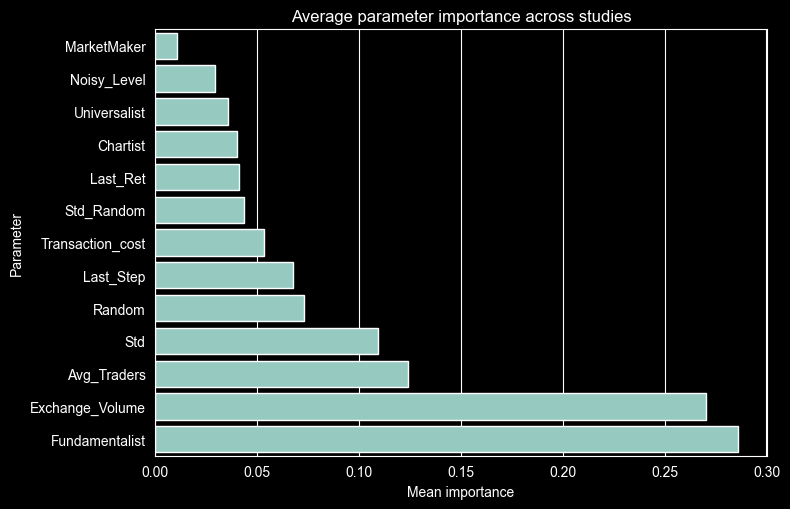

In [44]:
import seaborn as sns

table = pd.DataFrame([optuna.importance.get_param_importances(study) for study in studies])
s = table.mean().sort_values()
plt.figure(figsize=(8, max(4, len(s) * 0.4)))
sns.barplot(x=s.values, y=s.index, orient="h")
plt.xlabel("Mean importance")
plt.ylabel("Parameter")
plt.title("Average parameter importance across studies")
plt.tight_layout()
plt.show()